# Importing Modules

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [ ]:
df= pd.read_csv('/content/drive/MyDrive/train_test_dataset.csv')
df.head()

,S.No.,Temperature_K,Luminosity_Lo,Radius_Ro,Absolute_Magnitude,Star_Color,Spectral_Class,Star_Type
0,1,5132.872,1.159,1.084,6.011,Yellowish White,A,3
1,2,9295.788,0.013,0.009,14.534,White,D,2
2,3,5813.333,0.786,0.840,4.883,Blue White,G,3
3,4,5377.994,-0.070,0.811,5.598,White,F,3
4,5,5473.370,1.055,0.655,5.376,Yellowish White,G,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   S.No.               5000 non-null   int64  
 1   Temperature_K       4993 non-null   float64
 2   Luminosity_Lo       5000 non-null   float64
 3   Radius_Ro           5000 non-null   float64
 4   Absolute_Magnitude  5000 non-null   float64
 5   Star_Color          4808 non-null   object 
 6   Spectral_Class      4907 non-null   object 
 7   Star_Type           5000 non-null   int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 312.6+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(columns=['S.No.'], axis=1, inplace=True)

#EDA

##UNIVARIATE

### EDA ON TEMPERATURE

** CONCLUSIONS **



*   not normally distributed
*   0.14 percent of data is mising
*   There are outliers also





In [ ]:
df['Temperature_K'].describe()

,Temperature_K
count,4993.000000
mean,10617.476627
std,9581.598971
min,945.432000
25%,3510.095000
50%,7579.819000
75%,12321.679000
max,37911.340000


In [ ]:
df['Temperature_K'].isnull().sum() / len(df['Temperature_K'])

np.float64(0.0014)

0.14 percentage of data are missing

<Axes: ylabel='Frequency'>

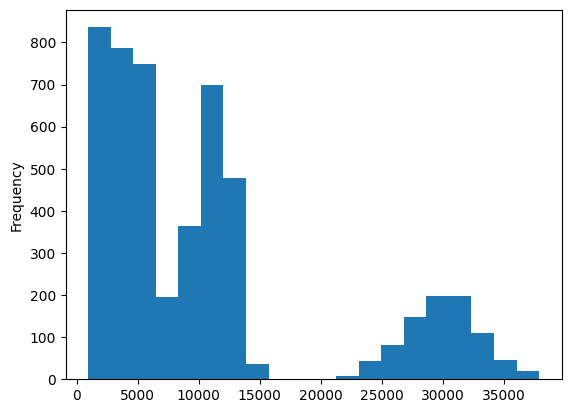

In [ ]:
df["Temperature_K"].plot(kind= 'hist', bins=20 )

<Axes: ylabel='Density'>

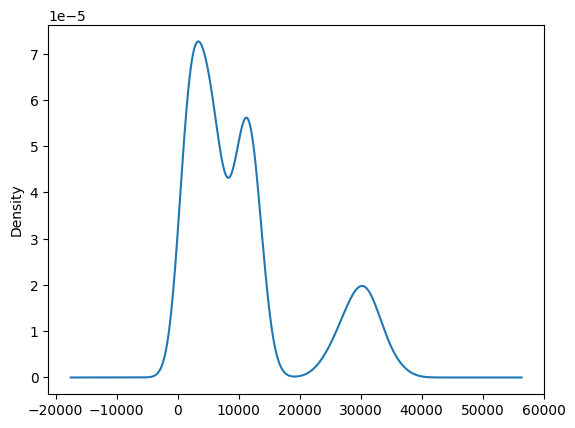

In [ ]:
df["Temperature_K"].plot(kind= 'kde' )

data is so much deviated from normal distribution as the skewness is greater than 1




In [ ]:
df["Temperature_K"].skew()

np.float64(1.2683491203609387)

<Axes: >

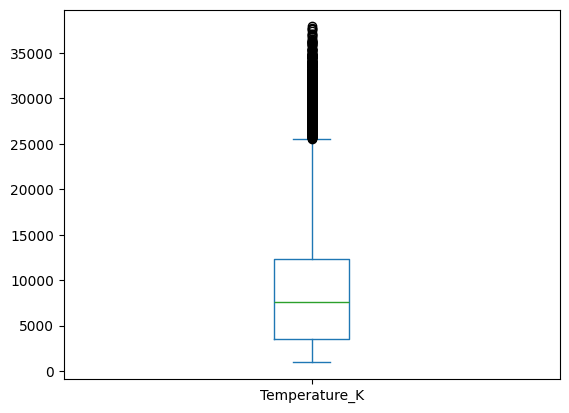

In [ ]:
df["Temperature_K"].plot(kind= 'box' )

This plot says that the outliers are present ater 25K units temperature

In [ ]:
df[df['Temperature_K']>25000]

,Temperature_K,Luminosity_Lo,Radius_Ro,Absolute_Magnitude,Star_Color,Spectral_Class,Star_Type
15,31403.384,107361.224,1266.089,-10.844,Blue,O,5
19,32746.206,103287.511,1341.072,-9.487,White,O,5
20,28967.758,107507.859,1401.712,-10.862,Blue,O,5
21,29230.109,96321.743,1882.120,-10.292,White,B,5
35,31852.923,112170.708,1567.886,-9.153,White,B,5
...,...,...,...,...,...,...,...
4975,33513.684,78236.338,1449.220,-10.588,Blue White,O,5
4980,26754.475,95809.698,1223.927,-10.797,Blue White,O,5
4991,26690.822,124517.126,1353.200,-7.867,White,B,5
4996,31268.803,115006.154,1513.587,-10.494,Blue White,B,5


### EDA on Luminosity

** CONCLUSIONS **


*   Highly postively skewed
*   no null values
*   Outliers are present





In [ ]:
df['Luminosity_Lo'].describe()

,Luminosity_Lo
count,5000.000000
mean,18847.727092
std,37342.169894
min,-0.784000
25%,0.010000
50%,0.349500
75%,10351.154750
max,129029.416000


In [ ]:
  df['Luminosity_Lo'].isnull().sum() / len(df['Luminosity_Lo'])

np.float64(0.0)

<Axes: ylabel='Frequency'>

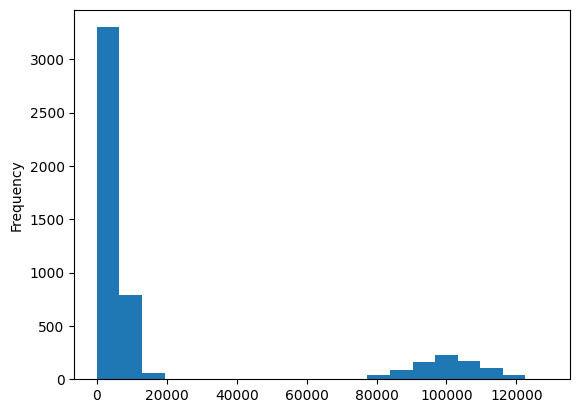

In [ ]:
df["Luminosity_Lo"].plot(kind= 'hist', bins=20 )

In [ ]:
df["Luminosity_Lo"].skew()

np.float64(1.7634746225071514)

<Axes: ylabel='Density'>

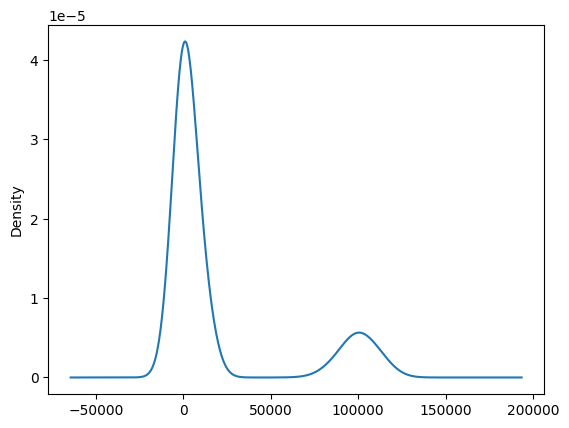

In [ ]:
df["Luminosity_Lo"].plot(kind= 'kde' )

<Axes: >

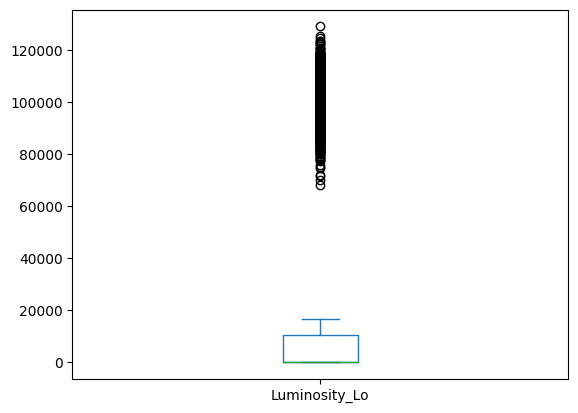

In [ ]:
df["Luminosity_Lo"].plot(kind= 'box' )

### EDA ON Radius

** CONCLUSIONS**


*  some radius are enegative
*  skewed graph




In [ ]:
df['Radius_Ro'].describe()

,Radius_Ro
count,5000.000000
mean,431.127198
std,627.566409
min,-0.157000
25%,0.103000
50%,0.799000
75%,1006.881000
max,2513.215000


In [ ]:
df[df['Radius_Ro']<0]

,Temperature_K,Luminosity_Lo,Radius_Ro,Absolute_Magnitude,Star_Color,Spectral_Class,Star_Type
2937,8859.693,0.009,-0.002,13.886,Blue White,D,2
4359,5861.930,0.644,-0.157,6.074,Yellowish White,F,3


In [ ]:
  df['Radius_Ro'].isnull().sum() / len(df['Radius_Ro'])

np.float64(0.0)

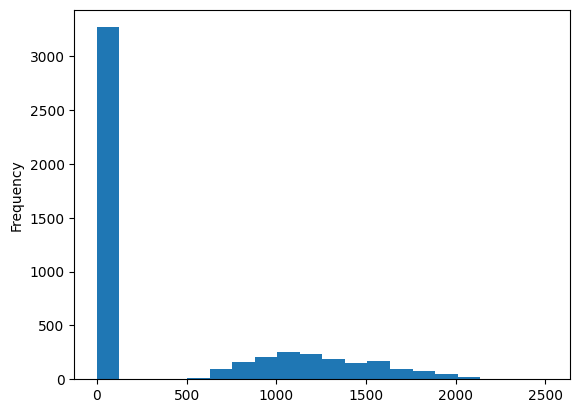

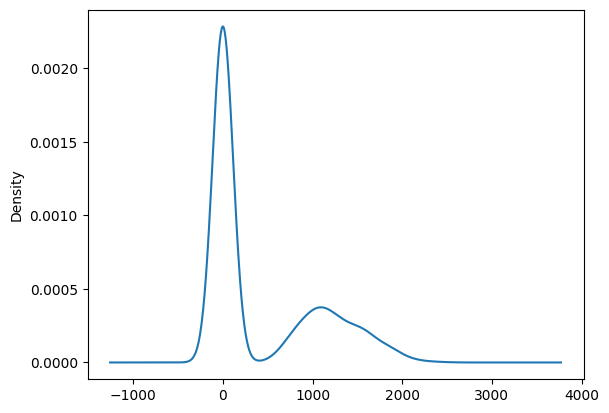

skewness 0.9981858081115482


<Axes: >

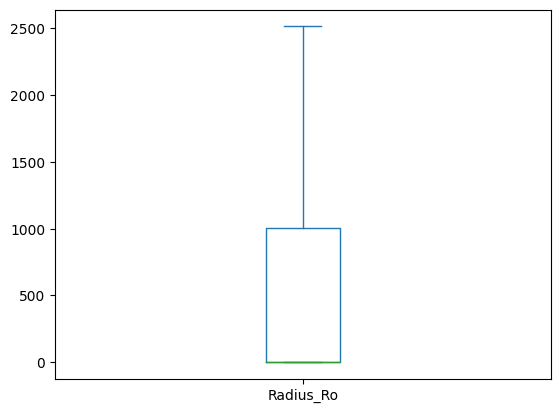

In [ ]:
df['Radius_Ro'].plot(kind= 'hist', bins=20 )
plt.show()
df['Radius_Ro'].plot(kind= 'kde' )
plt.show()
print('skewness',df['Radius_Ro'].skew())
df['Radius_Ro'].plot(kind= 'box' )

### EDA on absolute magn

**CONCLUSIONS**

1. lot of negative values
2. negatively *skewed*

In [ ]:
df['Absolute_Magnitude'].describe()

,Absolute_Magnitude
count,5000.000000
mean,5.920577
std,10.828736
min,-13.227000
25%,-5.100500
50%,6.333000
75%,14.955250
max,23.414000


In [ ]:
df[df['Absolute_Magnitude']<0]

,Temperature_K,Luminosity_Lo,Radius_Ro,Absolute_Magnitude,Star_Color,Spectral_Class,Star_Type
10,12324.084,9229.835,864.616,-4.388,NaN,A,4
15,31403.384,107361.224,1266.089,-10.844,Blue,O,5
19,32746.206,103287.511,1341.072,-9.487,White,O,5
20,28967.758,107507.859,1401.712,-10.862,Blue,O,5
21,29230.109,96321.743,1882.120,-10.292,White,B,5
...,...,...,...,...,...,...,...
4988,11433.074,11274.810,1266.714,-5.138,Blue,A,4
4991,26690.822,124517.126,1353.200,-7.867,White,B,5
4994,12277.554,10659.251,817.995,-4.605,Blue White,A,4
4996,31268.803,115006.154,1513.587,-10.494,Blue White,B,5


In [ ]:
  df['Absolute_Magnitude'].isnull().sum() / len(df['Absolute_Magnitude'])

np.float64(0.0)

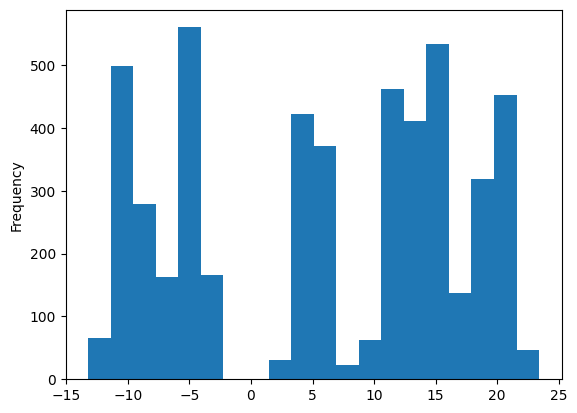

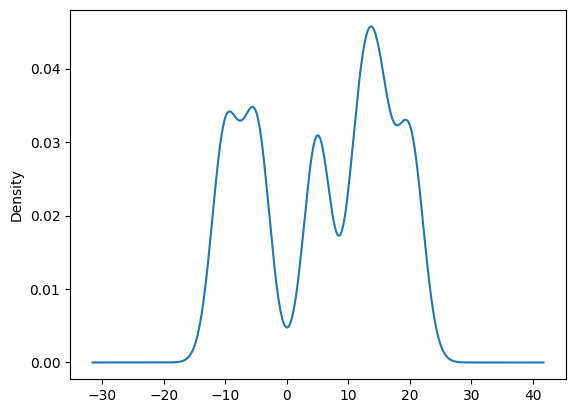

skewness -0.22360174836770658


<Axes: >

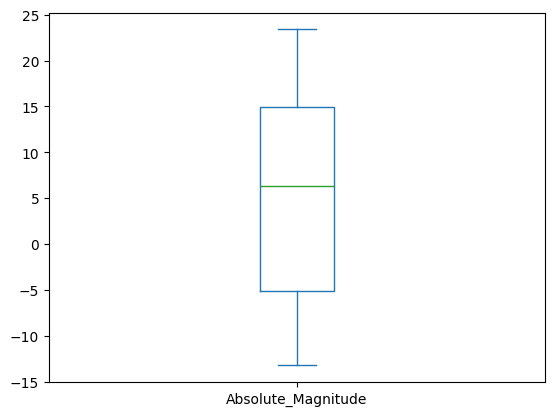

In [ ]:
df['Absolute_Magnitude'].plot(kind= 'hist', bins=20 )
plt.show()
df['Absolute_Magnitude'].plot(kind= 'kde' )
plt.show()
print('skewness',df['Absolute_Magnitude'].skew())
df['Absolute_Magnitude'].plot(kind= 'box' )

### EDA ON Startype

**CONCLUSIONS**

* star type data is balanced
*



In [ ]:
df['Star_Type'].value_counts()

,count
Star_Type,
4,880
5,850
3,846
0,826
2,814
1,784


In [ ]:
print(df["Star_Type"].isnull().sum())

0


<Axes: xlabel='Star_Type'>

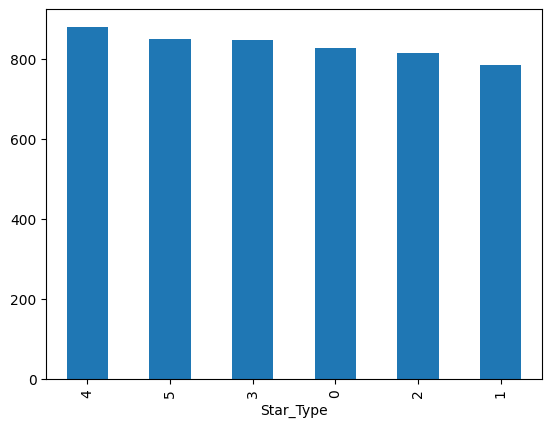

In [ ]:
df['Star_Type'].value_counts().plot(kind= 'bar')

<Axes: ylabel='count'>

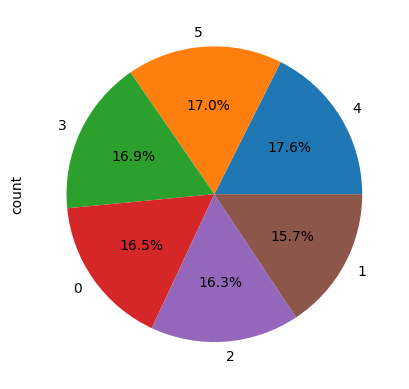

In [ ]:
df['Star_Type'].value_counts().plot(kind= 'pie', autopct='%1.1f%%')

### EDA on star color

In [ ]:
df['Star_Color'].value_counts()

,count
Star_Color,
Blue White,1081
White,967
Red,639
Blue,591
Brown,436
Yellowish,287
Yellowish White,272
Yellow,271
Orange,264


In [ ]:
df['Star_Color'].isnull().sum() / len(df['Star_Color'])

np.float64(0.0384)

<Axes: xlabel='Star_Color'>

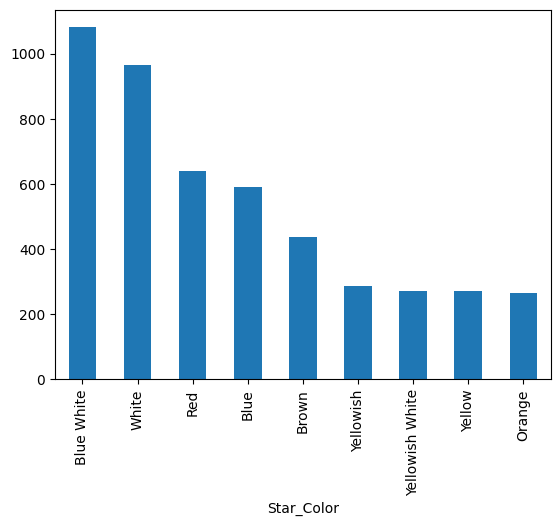

In [ ]:
df['Star_Color'].value_counts().plot(kind= 'bar')

<Axes: ylabel='count'>

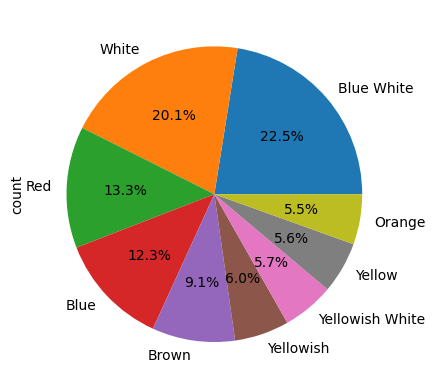

In [ ]:
df['Star_Color'].value_counts().plot(kind= 'pie', autopct='%1.1f%%')

### EDA on Spectral Class

In [ ]:
df['Spectral_Class'].value_counts()

,count
Spectral_Class,
M,1122
B,843
D,814
A,742
O,429
K,395
G,282
F,280


In [ ]:
df['Spectral_Class'].isnull().sum() / len(df['Spectral_Class'])

np.float64(0.0186)

<Axes: xlabel='Spectral_Class'>

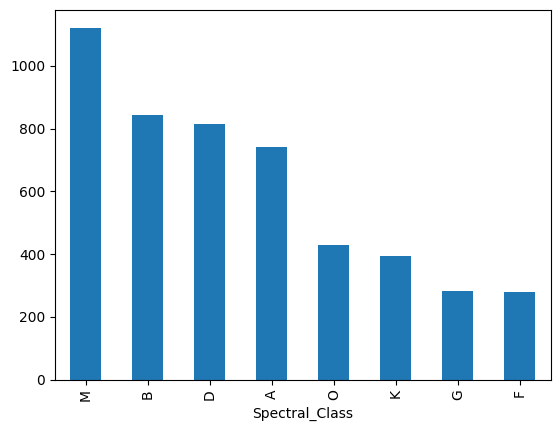

In [ ]:
df['Spectral_Class'].value_counts().plot(kind= 'bar')

<Axes: ylabel='count'>

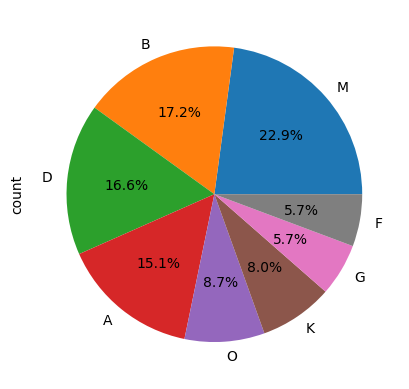

In [ ]:
df['Spectral_Class'].value_counts().plot(kind= 'pie', autopct='%1.1f%%')

In [ ]:
df['Spectral_Class']

,Spectral_Class
0,0
1,2
2,4
3,3
4,4
...,...
4995,3
4996,1
4997,2
4998,0


## BIVARIATE

**CONCLUSIONS**

1. with temperature:clear separation indicates that Temperature_K is a strong predictor of the Star Type
2. with luminosity: Luminosity_Lo is the most discriminative feature for Star Type, especially for: Separating type 5 stars (very luminous) and Differentiating type 4 from the dimmer types 0-3
3. with radius: Star Type 4 and 5 are well separated from Types 0-3 based on Radius_Ro.Just like Luminosity_Lo, Radius_Ro is another highly discriminative feature, especially for classifying higher star types.
4. with absolute magnitude: Each star type occupies relatively non-overlapping magnitude ranges.Especially clear distinctions between: Type 0 (very dim) and all others;Type 5 (brightest) and types 2, 1, 0. Types 3, 4, 5 have some overlap → not perfect, but still fairly distinguishable.

5. with star color: Star_Color is not a strong predictor of Star_Type due to High class overlap (shared colors across types)
6. with spectral class: Several Star Types are dominated by one or two Spectral Classes:
Type 2 is 100% Spectral_Class 2 → very predictable.
Type 0 is almost entirely Class 6.
Type 5 is split evenly between 1 and 7.
Some types like Type 3 are spread across multiple classes, making them harder to classify purely by spectral class.

Correlation between Star Type and Temperature_K: 0.8350042243098662
Correlation between Star Type and Luminosity_Lo: 0.697241617198407
Correlation between Star Type and Radius_Ro: 0.821694052665022
Correlation between Star Type and Absolute_Magnitude: -0.730278306354816


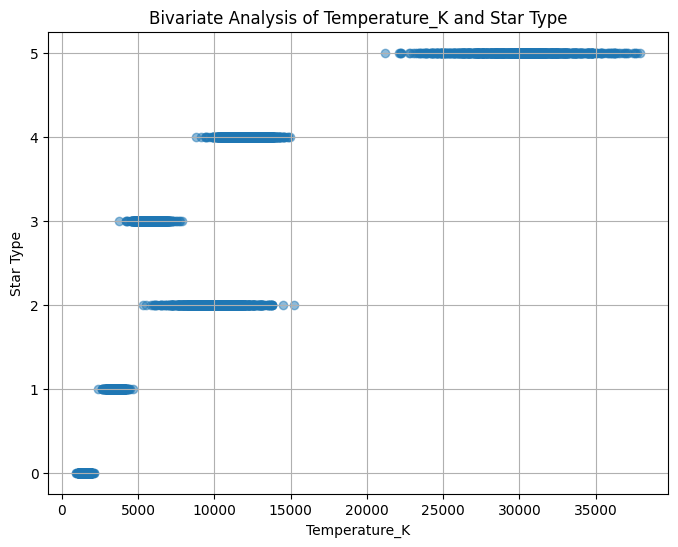

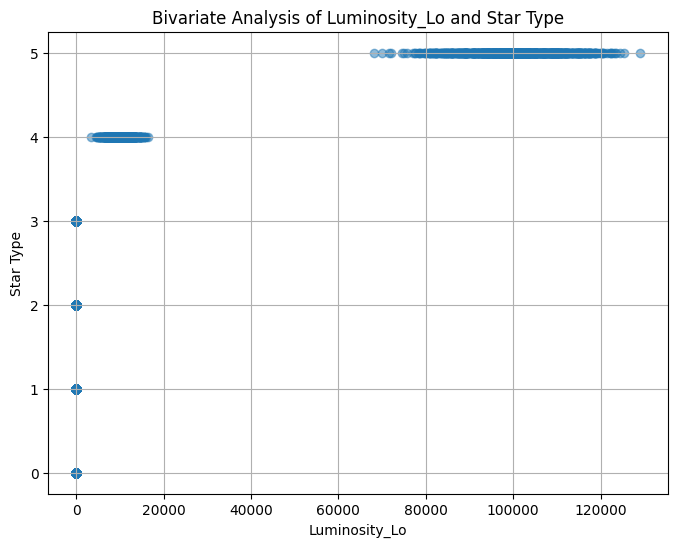

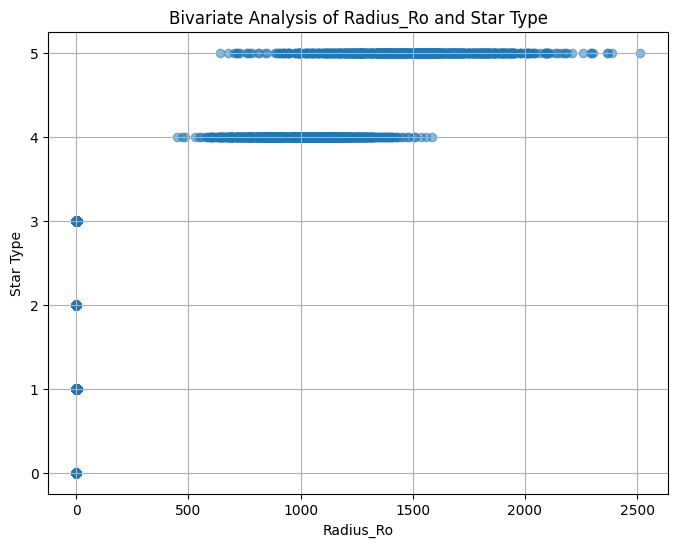

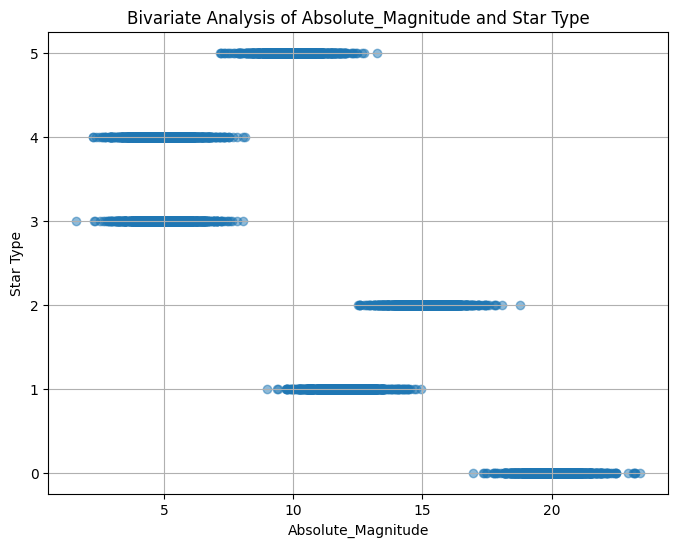


Contingency Table (Star Type vs Star Color):
Star_Color    0    1    2    3    4    5    6    7    8   9
Star_Type                                                  
0             0    0  436    0  390    0    0    0    0   0
1             0    0    0  264  249    0  271    0    0   0
2             0  335    0    0    0  418    0    0    0  56
3             0  259    0    0    0  273    0    0  272  42
4           301  243    0    0    0    0    0  287    0  47
5           289  241    0    0    0  274    0    0    0  46


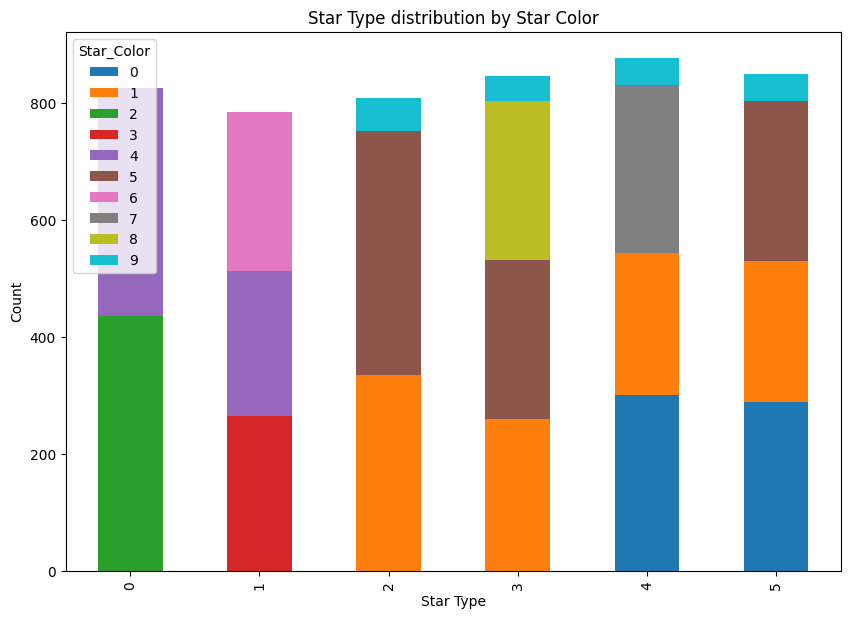


Contingency Table (Star Type vs Spectral Class):
Spectral_Class    0    1    2    3    4    5    6    7   8
Star_Type                                                 
0                 0    0    0    0    0    0  765    0  61
1                 0    0    0    0    0  395  357    0  32
2                 0    0  809    0    0    0    0    0   0
3               284    0    0  280  282    0    0    0   0
4               457  421    0    0    0    0    0    0   0
5                 0  421    0    0    0    0    0  429   0


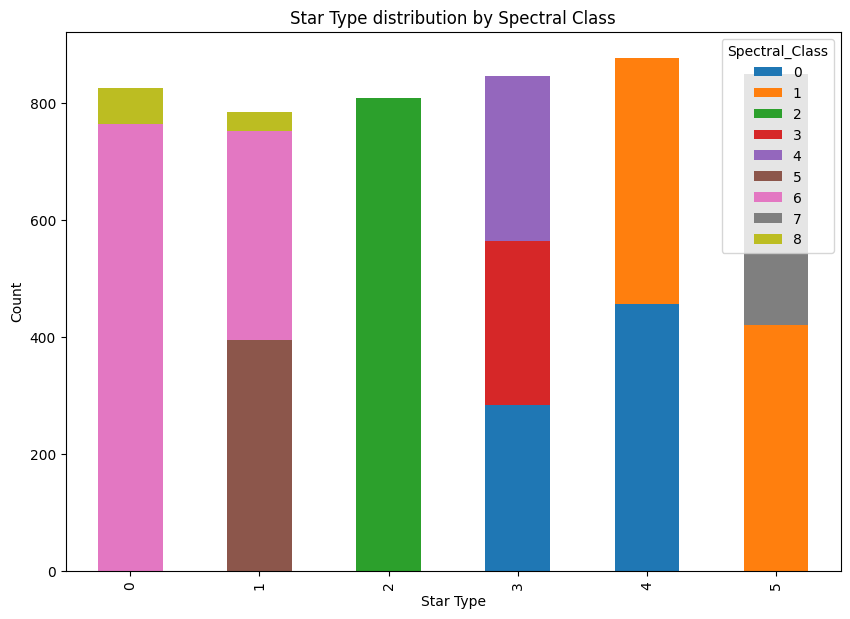

In [ ]:
numerical_cols = ['Temperature_K', 'Luminosity_Lo', 'Radius_Ro', 'Absolute_Magnitude']
for col in numerical_cols:
  correlation = df['Star_Type'].corr(df[col])
  print(f"Correlation between Star Type and {col}: {correlation}")

for col in numerical_cols:
  plt.figure(figsize=(8, 6))
  plt.scatter(df[col], df['Star_Type'], alpha=0.5)
  plt.title(f'Bivariate Analysis of {col} and Star Type')
  plt.xlabel(col)
  plt.ylabel('Star Type')
  plt.grid(True)
  plt.show()

contingency_color = pd.crosstab(df['Star_Type'], df['Star_Color'])
print("\nContingency Table (Star Type vs Star Color):")
print(contingency_color)

contingency_color.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Star Type distribution by Star Color')
plt.xlabel('Star Type')
plt.ylabel('Count')
plt.show()


contingency_spectral = pd.crosstab(df['Star_Type'], df['Spectral_Class'])
print("\nContingency Table (Star Type vs Spectral Class):")
print(contingency_spectral)

contingency_spectral.plot(kind='bar', stacked=True, figsize=(10, 7))
plt.title('Star Type distribution by Spectral Class')
plt.xlabel('Star Type')
plt.ylabel('Count')
plt.show()

# FEATURE ENGINEERING

In [ ]:
df['Radius_Ro']= abs(df['Radius_Ro'])
df['Absolute_Magnitude']= abs(df['Absolute_Magnitude'])

In [ ]:

df.dropna(subset=['Temperature_K'], inplace=True)
df.dropna(subset=['Star_Color'], inplace=True)
df.dropna(subset=['Spectral_Class'], inplace=True)

In [ ]:
df.isnull().sum()

,0
Temperature_K,0
Luminosity_Lo,0
Radius_Ro,0
Absolute_Magnitude,0
Star_Color,0
Spectral_Class,0
Star_Type,0


# Encoding

In [ ]:
df['Star_Color']

,Star_Color
0,8
1,5
2,1
3,5
4,8
...,...
4995,5
4996,1
4997,5
4998,1


In [ ]:
le_star_color = LabelEncoder()
df['Star_Color'] = le_star_color.fit_transform(df['Star_Color'])

le_spectral_class = LabelEncoder()
df['Spectral_Class'] = le_spectral_class.fit_transform(df['Spectral_Class'])

# correlation between the columns

** CONCLUSIONS **
1. Temperature is the most influential factor in determining Star_Type, followed closely by radius.

2. Luminosity also plays an important role but is slightly less correlated than temperature and radius.

3. Absolute Magnitude shows a negative correlation — this makes sense because brighter stars have lower (more negative) magnitudes and are typically of a higher type.

4. All features have significant correlations (|r| > 0.65), indicating that they are relevant predictors for classifying star types.



In [ ]:
df_encoded = df.drop(columns=['Star_Color', 'Spectral_Class'])

correlation_matrix = df_encoded.corr()
star_type_correlation = correlation_matrix['Star_Type'].sort_values(ascending=False)

print("Correlation of Star Type with other numerical columns:")
star_type_correlation

Correlation of Star Type with other numerical columns:


,Star_Type
Star_Type,1.000000
Temperature_K,0.835004
Radius_Ro,0.821694
Luminosity_Lo,0.697242
Absolute_Magnitude,-0.730278


# Standardising dataset

In [ ]:
X=df.drop(columns='Star_Type',axis=1)
Y=df['Star_Type']

In [ ]:
Scalar=StandardScaler()
Scalar.fit(X)
std_data=Scalar.transform(X)

In [ ]:
print(std_data)

[[-0.57246749 -0.50508205 -0.68544454 -0.92196809  1.7150837  -1.35108053]
 [-0.13795411 -0.50511272 -0.68715716  0.63479946  0.56258992 -0.55189263]
 [-0.5014429  -0.50509203 -0.68583326 -1.12800279 -0.97406844  0.24729528]
 ...
 [-0.28899341 -0.50511261 -0.68715876  0.97289365  0.56258992 -0.55189263]
 [-0.49342705 -0.50506719 -0.68491402 -1.1227058  -0.97406844 -1.35108053]
 [ 2.51387129  2.09539123  1.7827597  -0.53510505 -1.35823303  1.44607713]]


# Test train split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)
print(X.shape,x_train.shape,x_test.shape)

(4993, 6) (3994, 6) (999, 6)


# Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train,y_train)
x_train_prediction=model.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)
print('training_data_accuracy=',training_data_accuracy)
x_test_prediction=model.predict(x_test)
testing_data_accuracy=accuracy_score(x_test_prediction,y_test)
print('testing_data_accuracy=',testing_data_accuracy)

training_data_accuracy= 1.0
testing_data_accuracy= 1.0


# model performance

** CONCLUSIONS **

model's performance is perfect on the test set:
It made zero errors.

1. 100% Accuracy
2.  Every class was predicted exactly as it was labeled — no overlap or confusion between classes.
3. This level of performance is rare and typically only seen in: Very well-separated datasets

## on test data

Accuracy: 1.0
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1 Score: 1.0
Weighted F1 Score: 1.0
Macro F2 Score: 0.99999999998
Weighted F2 Score: 0.99999999998

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       165
           1       1.00      1.00      1.00       157
           2       1.00      1.00      1.00       162
           3       1.00      1.00      1.00       169
           4       1.00      1.00      1.00       176
           5       1.00      1.00      1.00       170

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999



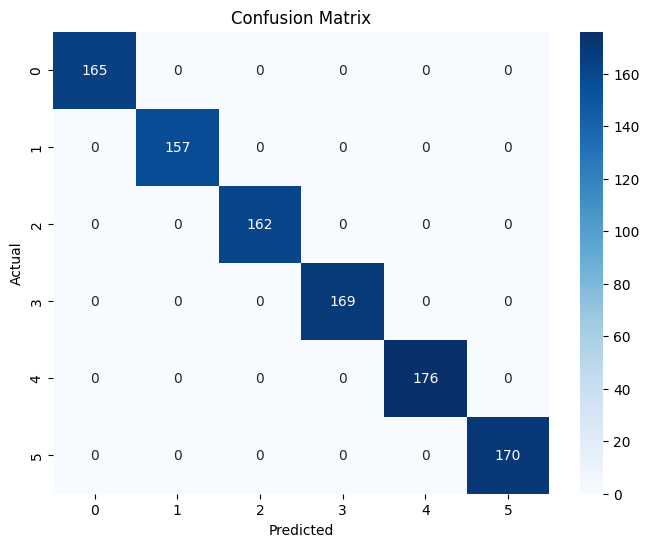

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    make_scorer,precision_recall_fscore_support
)


y_pred = model.predict(x_test)

acc = accuracy_score(y_test, y_pred)

precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

def fbeta_score_custom(y_true, y_pred, beta=2.0, average='macro'):
    p, r, _, _ = precision_recall_fscore_support(y_true, y_pred, average=average, zero_division=0)
    beta_sq = beta ** 2
    return (1 + beta_sq) * (p * r) / (beta_sq * p + r + 1e-10)  # avoid divide-by-zero

f2_macro = fbeta_score_custom(y_test, y_pred, beta=2, average='macro')
f2_weighted = fbeta_score_custom(y_test, y_pred, beta=2, average='weighted')

cm = confusion_matrix(y_test, y_pred)


print("Accuracy:", acc)
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1 Score:", f1_macro)
print("Weighted F1 Score:", f1_weighted)
print("Macro F2 Score:", f2_macro)
print("Weighted F2 Score:", f2_weighted)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

#heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Cross validation

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
cv = StratifiedKFold(n_splits=5)
scores = cross_val_score(model, X, Y, cv=cv)

print("Accuracy scores:", scores)
print("Mean accuracy:", scores.mean())

Accuracy scores: [1. 1. 1. 1. 1.]
Mean accuracy: 1.0


##  Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Random Forest model
rf = RandomForestClassifier(random_state=42)

# Randomized Search with 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit the model
random_search.fit(x_train, y_train)

# Predict and evaluate
y_pred = random_search.predict(x_test)

print("Best Parameters:", random_search.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       165
           1       1.00      1.00      1.00       157
           2       1.00      1.00      1.00       162
           3       1.00      1.00      1.00       169
           4       1.00      1.00      1.00       176
           5       1.00      1.00      1.00       170

    accuracy                           1.00       999
   macro avg       1.00      1.00      1.00       999
weighted avg       1.00      1.00      1.00       999


Confusion Matrix:
 [[165   0   0   0   0   0]
 [  0 157   0   0   0   0]
 [  0   0 162   0   0   0]
 [  0   0   0 169   0   0]
 [  0   0   0   0 176   0]
 [  0   0   0   0   0 170]]


# Feature importance from RF
** CONCLUSIONS **
1. More important features- temp, luminosity,radius.abs magnb
2. least importance- star color and spectral class

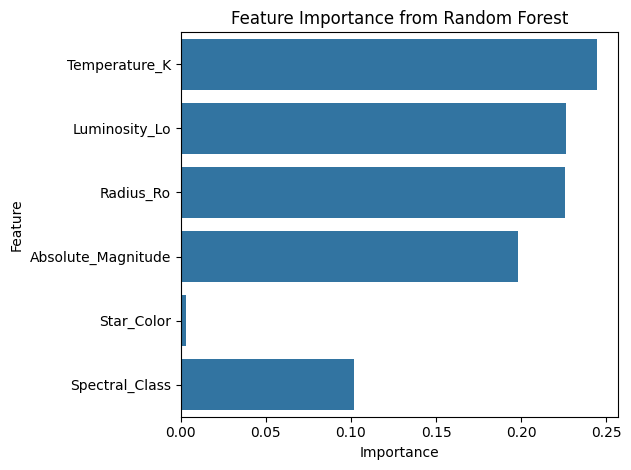

In [ ]:
importances = random_search.best_estimator_.feature_importances_
feature_names = X.columns

# Plotting
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# permutation importance
** CONCLUSIONS **
1. This contradicts the built-in Random Forest importance, where Temperature_K and Luminosity_Lo were dominant

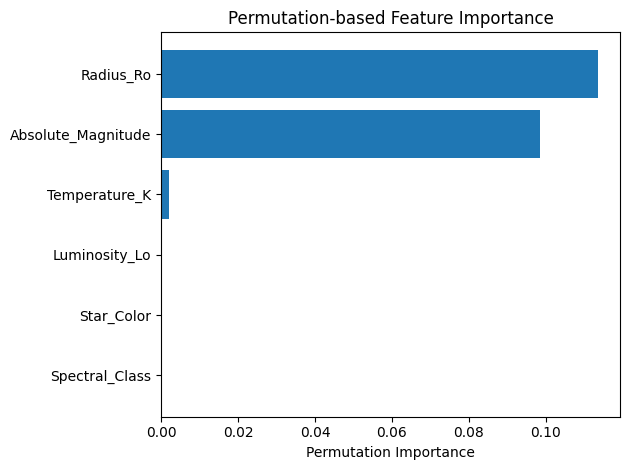

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(random_search.best_estimator_, x_test, y_test, n_repeats=10, random_state=42)

# Plot
sorted_idx = result.importances_mean.argsort()
plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Permutation-based Feature Importance")
plt.tight_layout()
plt.show()


# SHAP plots

** CONCLUSIONS ""
1. Radius_Ro, Temperature_K, and Absolute_Magnitude are consistently important, aligning with earlier insights.

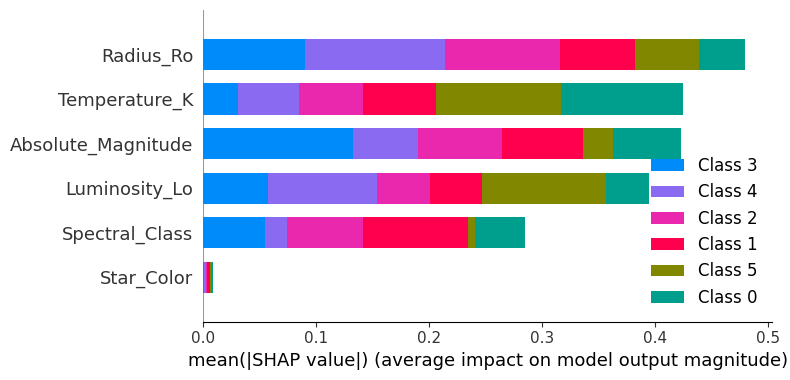

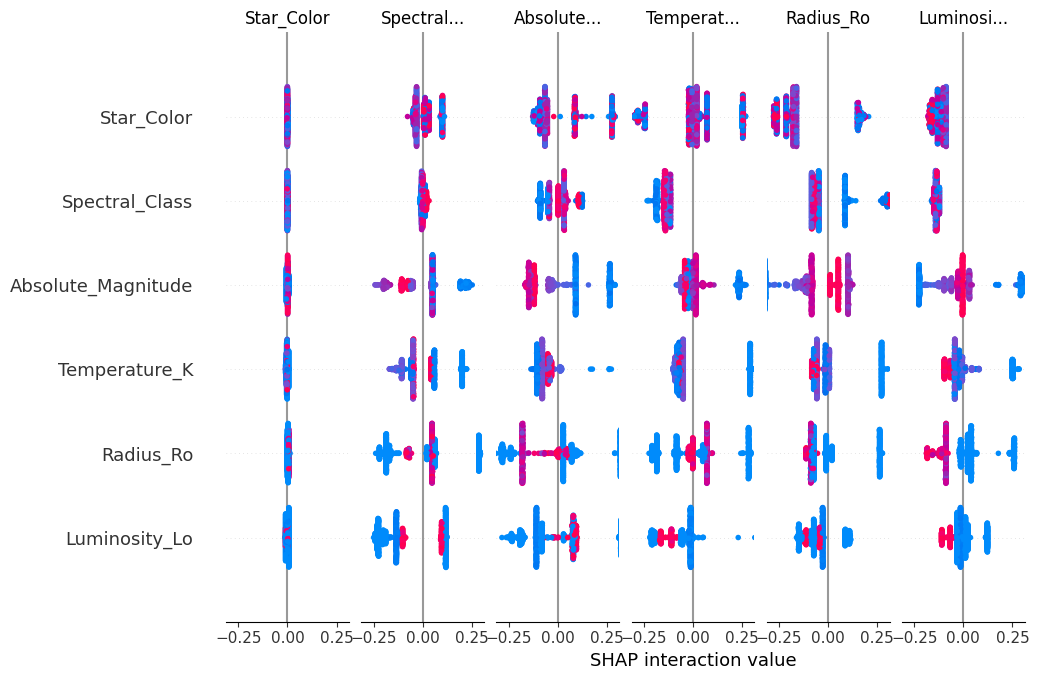

In [ ]:
explainer = shap.TreeExplainer(random_search.best_estimator_)
shap_values = explainer.shap_values(x_test)

# Summary Plot (Global Feature Importance)
shap.summary_plot(shap_values, x_test, plot_type="bar")

# Detailed Summary (Beeswarm plot)
shap.summary_plot(shap_values, x_test)

# Individual Prediction (Local Explanation)
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1][0], x_test.iloc[0])

# validating a  new dataset

## data preprocessing

In [ ]:
data= pd.read_csv('/content/drive/MyDrive/validate_dataset.csv')
data.dropna(inplace=True)
print(data.isnull().sum())


S.No.                 0
Temperature_K         0
Luminosity_Lo         0
Radius_Ro             0
Absolute_Magnitude    0
Star_Color            0
Spectral_Class        0
dtype: int64


In [ ]:
le = LabelEncoder()
data['Spectral_Class'] = le.fit_transform(data['Spectral_Class'])
data['Star_Color'] = le.fit_transform(data['Star_Color'])
print(data)

     S.No.  Temperature_K  Luminosity_Lo  Radius_Ro  Absolute_Magnitude  \
0        1           3068       0.002400     0.1700               16.12   
1        2           3042       0.000500     0.1542               16.60   
2        3           2600       0.000300     0.1020               18.70   
3        4           2800       0.000200     0.1600               16.65   
4        5           1939       0.000138     0.1030               20.06   
..     ...            ...            ...        ...                 ...   
235    236          38940  374830.000000  1356.0000               -9.93   
236    237          30839  834042.000000  1194.0000              -10.63   
237    238           8829  537493.000000  1423.0000              -10.73   
238    239           9235  404940.000000  1112.0000              -11.23   
239    240          37882  294903.000000  1783.0000               -7.80   

     Star_Color  Spectral_Class  
0             8               5  
1             8               5

## Star decoder

In [ ]:
def decode_star_type(code):
    if code == 0:
        return "Red Dwarf"
    elif code == 1:
        return "Brown Dwarf"
    elif code == 2:
        return "White Dwarf"
    elif code == 3:
        return "Main Sequence"
    elif code == 4:
        return "Supergiant"
    elif code == 5:
        return "Hypergiant"

## Predicting the star type

In [ ]:
Scalar=StandardScaler()
Scalar.fit(data)
fin_data=Scalar.transform(data)
data.drop(columns=['S.No.'], axis=1, inplace=True)

In [ ]:
data.head()

,Temperature_K,Luminosity_Lo,Radius_Ro,Absolute_Magnitude,Star_Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,8,5
1,3042,0.000500,0.1542,16.60,8,5
2,2600,0.000300,0.1020,18.70,8,5
3,2800,0.000200,0.1600,16.65,8,5
4,1939,0.000138,0.1030,20.06,8,5


In [ ]:
predicted_star_type= model.predict(data)
print(predicted_star_type)

[1 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 5 3 3 3 3 3 3
 3 3 3 5 5 5 5 5 5 5 5 5 5 4 4 5 4 4 4 4 4 5 4 1 0 1 0 0 0 0 0 0 0 1 1 1 1
 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 5 5 5 5 5 5 5 5 5 5 5 4
 5 4 4 4 4 4 5 4 4 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2
 2 2 5 3 3 3 3 3 3 3 3 5 5 5 5 5 5 5 5 5 5 5 4 4 4 5 5 4 5 4 4 5 0 0 0 0 0
 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 5 5 3 3 3 3 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 4 5]


In [ ]:
L=[]
for i in predicted_star_type:
  L.append(decode_star_type(i))

## The predicted star type is stored in result_file.csv

In [ ]:
data["predicted_startype"]= L
data.to_csv("Result_file.csv", index=False)
data.drop(columns=['predicted_startype'], axis=1, inplace=True)


In [ ]:
result_data=pd.read_csv('/content/Result_file.csv')
print(result_data)

     Temperature_K  Luminosity_Lo  Radius_Ro  Absolute_Magnitude  Star_Color  \
0             3068       0.002400     0.1700               16.12           8   
1             3042       0.000500     0.1542               16.60           8   
2             2600       0.000300     0.1020               18.70           8   
3             2800       0.000200     0.1600               16.65           8   
4             1939       0.000138     0.1030               20.06           8   
..             ...            ...        ...                 ...         ...   
235          38940  374830.000000  1356.0000               -9.93           0   
236          30839  834042.000000  1194.0000              -10.63           0   
237           8829  537493.000000  1423.0000              -10.73           9   
238           9235  404940.000000  1112.0000              -11.23           9   
239          37882  294903.000000  1783.0000               -7.80           0   

     Spectral_Class predicted_startype 

# SHAP Analysis (INDIVIDUAL)

** CONCLUSIONS **
1. Luminosity_Lo:Has the highest average SHAP value → it's by far the most important feature.Dominantly influences Class 6 and Class 1 (indicated by the longest blue and red segments).

2. Temperature_K and Radius_Ro:Have small but non-zero importance.Also contribute to Class 1 and other minor classes.

3. All other features (Absolute_Magnitude, Spectral_Class, Star_Color): Have negligible influence on the model predictions.

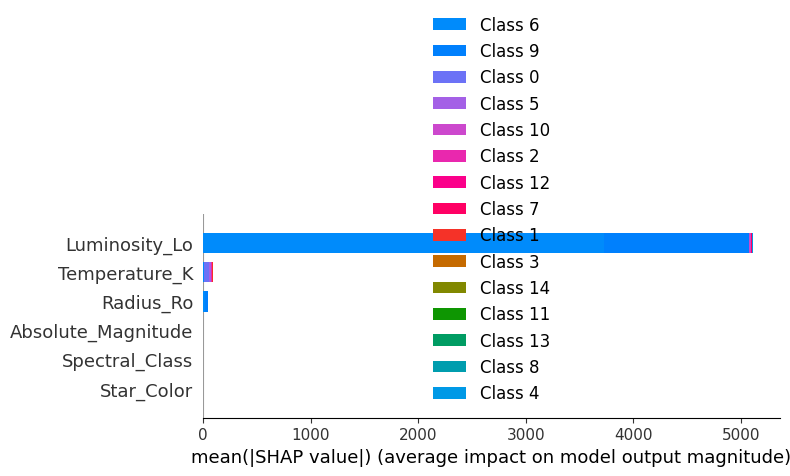

In [ ]:
import shap

explainer = shap.Explainer(classifier, x_train)
shap_values = explainer(x_test)

shap.summary_plot(shap_values, x_test)


# Deployment using Gradio

In [ ]:
import gradio as gr

In [ ]:
def predict_star_type(temp, lum, rad, mag, color, spectral):


  fin = [float(temp), float(lum), float(rad), float(mag), color, spectral]

  flipped_color = {label: i for i, label in enumerate(le.classes_)}
  flipped_spectral = {'A':0, 'B':1,'D':2,'F':3,'G':4,'K':5,'M':6,'O':7 }
  print(flipped_color)
  print(flipped_spectral)

  fin[4]= flipped_color[fin[4]]

  fin[5]= flipped_spectral[fin[5]]

  print(fin[5])

  L1=np.array(fin)
  print(L1)
  L1.reshape(1,-1)
  code=int(model.predict([L1])[0])
  print(code)


  code_to_type = {
    0: "Red Dwarf",
    1: "Brown Dwarf",
    2: "White Dwarf",
    3: "Main Sequence",
    4: "Supergiant",
    5: "Hypergiant"}
  return code_to_type.get(code, "Unknown")

a,b,c,d,e,f= 5132.872,1.159,1.084,6.011,'Yellowish White','A'
print(predict_star_type(a,b,c,d,e,f))



{'Blue': 0, 'Blue White': 1, 'Blue white': 2, 'Blue-White': 3, 'Blue-white': 4, 'Orange': 5, 'Orange-Red': 6, 'Pale yellow orange': 7, 'Red': 8, 'White': 9, 'White-Yellow': 10, 'Whitish': 11, 'Yellowish': 12, 'Yellowish White': 13, 'white': 14, 'yellow-white': 15, 'yellowish': 16}
{'A': 0, 'B': 1, 'D': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6, 'O': 7}
0
[5.132872e+03 1.159000e+00 1.084000e+00 6.011000e+00 1.300000e+01
 0.000000e+00]
3
Main Sequence


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
inputs = [
    gr.Number(label="Temperature (K)"),
    gr.Number(label="Luminosity (L/Lo)"),
    gr.Number(label="Radius (R/Ro)"),
    gr.Number(label="Absolute Magnitude"),
    gr.Dropdown(choices=["Blue", "White", "Yellowish White", "Blue White", "Orange", "Orange-Red"], label="Star Color"),
    gr.Dropdown(choices=["O", "B", "A", "F", "G", "K", "M"], label="Spectral Class")
]

output = gr.Textbox(label="Prediction")



In [ ]:
gr.Interface(
    fn=predict_star_type,
    inputs=inputs,
    outputs=output,
    title="Star Classification UI",
    description="Enter star features to predict its type (Red Dwarf, Supergiant, etc.)."
).launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://936f84568651f9e5ae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
